In [1]:
# Setup automatico para Google Colab: clona o repo para ter acesso ao
# modulo .py e ao dataset desta pasta (sem efeito quando rodado localmente).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Algoritmos-Base/04-Regressao-Polinomial-Ridge")
    get_ipython().system('pip install -q openpyxl')


# Regressao Polinomial com Regularizacao L2 (Ridge)

Traduzido de `Codigo01_Seno_Regularizacao.R`.

Um polinomio de grau alto ajustado por minimos quadrados tende a overfitar
dados ruidosos (oscila para acompanhar cada ponto). A **regularizacao Ridge**
penaliza coeficientes grandes, trocando um pouco de vies por uma reducao
importante de variancia.

## Teoria

Modelo: $\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_p x^p$
(aqui, $p=8$).

**OLS** minimiza apenas o erro quadratico:

$$\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty$$

**Ridge** adiciona uma penalidade $L_2$ sobre os coeficientes (exceto o
intercepto):

$$\hat{\beta}_{Ridge} = \underset{\beta}{\text{argmin}} \; \|y - X\beta\|^2 + \lambda\|\beta_{1:p}\|^2
= (X^TX + \lambda I')^{-1}X^Ty$$

onde $I'$ e a identidade com a primeira posicao (intercepto) zerada, para
nao penalizar o nivel medio da funcao.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ridge_regularizacao import load_data, build_polynomial_features, fit_polynomial_ols, fit_ridge, predict

plt.rcParams["figure.figsize"] = (7, 4.5)


In [3]:
dt = load_data("data/Seno.xlsx")
x = dt["x"].to_numpy(dtype=float)
y = dt["y"].to_numpy(dtype=float)

X = build_polynomial_features(x, degree=8)
print("Shape da matriz de design (com intercepto):", X.shape)


Shape da matriz de design (com intercepto): (100, 9)


## Ajuste OLS (polinomio grau 8, sem regularizacao)


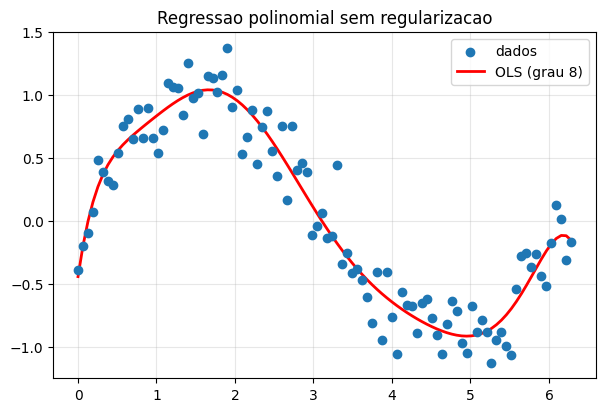

In [4]:
beta_ols = fit_polynomial_ols(X, y)
y_hat_ols = predict(X, beta_ols)

order = np.argsort(x)
plt.scatter(x, y, color="tab:blue", label="dados", zorder=3)
plt.plot(x[order], y_hat_ols[order], color="red", lw=2, label="OLS (grau 8)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Regressao polinomial sem regularizacao")
plt.show()


## Ajuste Ridge

### Escolha do hiperparametro

- **`lambda = 0.5`**: mesmo valor usado no script original em R. E um
  valor moderado — grande o suficiente para reduzir visivelmente a
  amplitude dos coeficientes de graus mais altos (que sao os que mais
  contribuem para o overfitting), sem "achatar" o ajuste a ponto de perder
  a curvatura real do seno.


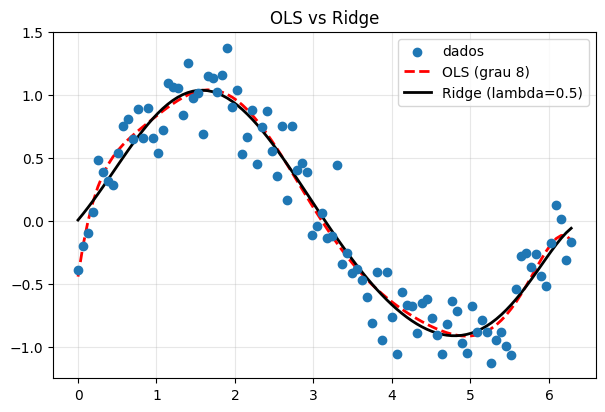

In [5]:
beta_ridge = fit_ridge(X, y, lam=0.5)
y_hat_ridge = predict(X, beta_ridge)

plt.scatter(x, y, color="tab:blue", label="dados", zorder=3)
plt.plot(x[order], y_hat_ols[order], color="red", lw=2, ls="--", label="OLS (grau 8)")
plt.plot(x[order], y_hat_ridge[order], color="black", lw=2, label="Ridge (lambda=0.5)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("OLS vs Ridge")
plt.show()


## Efeito da regularizacao sobre os coeficientes

Ridge encolhe (`shrinkage`) os coeficientes em direcao a zero — mas nao os
zera, diferente do Lasso (L1). O grafico abaixo mostra a magnitude de cada
coeficiente polinomial nas duas solucoes.

**Cuidado ao interpretar esse grafico**: `x` varia de 0 a ~6.28, mas `x^8`
varia de 0 a ~2.4 milhoes. Isso significa que o coeficiente de grau 8 *ja
nasce* minusculo no OLS (ele precisa ser pequeno, porque multiplica um
numero gigante) — nao e o Ridge que o encolhe visualmente, ele ja e pequeno
antes de qualquer regularizacao. Comparar coeficientes brutos de graus tao
diferentes no mesmo eixo linear e enganoso; a celula seguinte mostra a
**reducao percentual** por grau, que e comparavel entre graus e revela que
o encolhimento NAO segue um padrao simples "quanto maior o grau, mais
encolhe" — a colinearidade entre os termos polinomiais faz o efeito real
ser mais complexo do que a intuicao sugere.


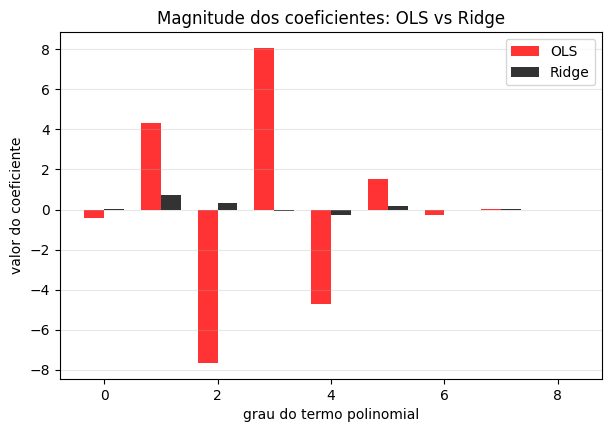

Norma L2 dos coeficientes (exceto intercepto) - OLS  : 12.9186
Norma L2 dos coeficientes (exceto intercepto) - Ridge: 0.8743


In [6]:
degrees = np.arange(len(beta_ols))
width = 0.35

plt.bar(degrees - width / 2, beta_ols, width, label="OLS", color="red", alpha=0.8)
plt.bar(degrees + width / 2, beta_ridge, width, label="Ridge", color="black", alpha=0.8)
plt.xlabel("grau do termo polinomial")
plt.ylabel("valor do coeficiente")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.title("Magnitude dos coeficientes: OLS vs Ridge")
plt.show()

print(f"Norma L2 dos coeficientes (exceto intercepto) - OLS  : {np.linalg.norm(beta_ols[1:]):.4f}")
print(f"Norma L2 dos coeficientes (exceto intercepto) - Ridge: {np.linalg.norm(beta_ridge[1:]):.4f}")


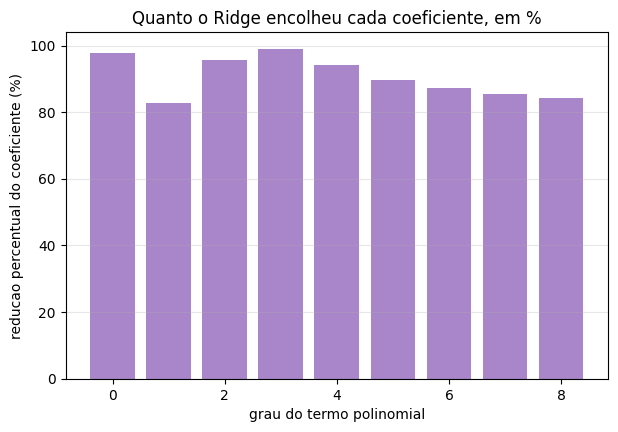

grau 0: 97.8% de reducao


grau 1: 82.8% de reducao
grau 2: 95.8% de reducao
grau 3: 99.0% de reducao
grau 4: 94.1% de reducao
grau 5: 89.7% de reducao
grau 6: 87.2% de reducao
grau 7: 85.5% de reducao
grau 8: 84.3% de reducao


In [7]:
# Reducao percentual por grau (comparavel entre graus, ao contrario do valor bruto)
reducao_pct = (1 - np.abs(beta_ridge) / np.abs(beta_ols)) * 100

plt.bar(degrees, reducao_pct, color="tab:purple", alpha=0.8)
plt.xlabel("grau do termo polinomial")
plt.ylabel("reducao percentual do coeficiente (%)")
plt.title("Quanto o Ridge encolheu cada coeficiente, em %")
plt.grid(alpha=0.3, axis="y")
plt.show()

for d, r in zip(degrees, reducao_pct):
    print(f"grau {d}: {r:.1f}% de reducao")


## Estabilidade dos coeficientes entre amostras (viés-variância)

O motivo real para aceitar Ridge (mais erro no treino) é a **variância**:
coeficientes grandes reagem fortemente ao ruído específico de uma amostra;
coeficientes pequenos reagem pouco. Para tornar isso concreto, simulamos
uma segunda amostra do mesmo seno (mesma função, ruído diferente) e
comparamos o quanto os coeficientes de OLS e Ridge mudam entre as duas
amostras.


Norma dos coeficientes OLS   -> amostra 1: 12.919   amostra 2: 3.042   variacao: 9.877
Norma dos coeficientes Ridge -> amostra 1: 0.874   amostra 2: 0.533   variacao: 0.341


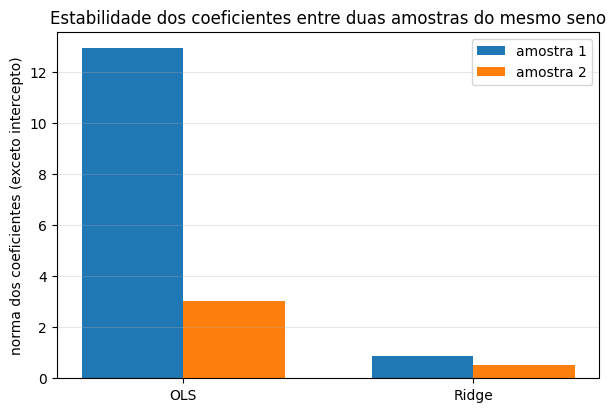

In [8]:
rng = np.random.default_rng(0)
ruido_padrao = np.std(y - np.sin(x))
y_amostra2 = np.sin(x) + rng.normal(0, ruido_padrao, size=len(x))

beta_ols_2 = fit_polynomial_ols(X, y_amostra2)
beta_ridge_2 = fit_ridge(X, y_amostra2, lam=0.5)

norma_ols = [np.linalg.norm(beta_ols[1:]), np.linalg.norm(beta_ols_2[1:])]
norma_ridge = [np.linalg.norm(beta_ridge[1:]), np.linalg.norm(beta_ridge_2[1:])]

print(f"Norma dos coeficientes OLS   -> amostra 1: {norma_ols[0]:.3f}   amostra 2: {norma_ols[1]:.3f}   variacao: {abs(norma_ols[0]-norma_ols[1]):.3f}")
print(f"Norma dos coeficientes Ridge -> amostra 1: {norma_ridge[0]:.3f}   amostra 2: {norma_ridge[1]:.3f}   variacao: {abs(norma_ridge[0]-norma_ridge[1]):.3f}")

x_labels = ["OLS", "Ridge"]
largura = 0.35
posicoes = np.arange(2)
plt.bar(posicoes - largura/2, [norma_ols[0], norma_ridge[0]], largura, label="amostra 1", color="tab:blue")
plt.bar(posicoes + largura/2, [norma_ols[1], norma_ridge[1]], largura, label="amostra 2", color="tab:orange")
plt.xticks(posicoes, x_labels)
plt.ylabel("norma dos coeficientes (exceto intercepto)")
plt.title("Estabilidade dos coeficientes entre duas amostras do mesmo seno")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.show()


O conjunto de coeficientes do OLS muda drasticamente entre as duas amostras
(a norma despenca ou dispara) — o modelo está perseguindo o ruído
específico de cada amostra, não só o padrão do seno. O Ridge varia muito
menos: essa é a troca real por trás do `lambda` — um pouco mais de erro
*nesta* amostra, em troca de um modelo que generaliza melhor para dados
novos, porque não decora o ruído de uma amostra específica.


## Interpretacao das metricas

Espera-se que o RMSE de treino do OLS seja levemente menor que o do Ridge
(o OLS minimiza exatamente o erro de treino), mas isso nao significa melhor
generalizacao — o polinomio de grau 8 sem penalizacao tende a acompanhar
ruido especifico dessa amostra.


In [9]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


print(f"OLS   -> RMSE: {rmse(y, y_hat_ols):.5f}, R2: {r_squared(y, y_hat_ols):.5f}")
print(f"Ridge -> RMSE: {rmse(y, y_hat_ridge):.5f}, R2: {r_squared(y, y_hat_ridge):.5f}")


OLS   -> RMSE: 0.18962, R2: 0.92924
Ridge -> RMSE: 0.20087, R2: 0.92059


## Conclusao

Regularizacao L2 e uma ferramenta geral de controle de complexidade,
aplicavel tanto a regressao linear/polinomial quanto aos pesos de uma rede
neural (weight decay). O ultimo notebook desta serie
(`05-MLP-Hyperparameter-Search/`) volta ao MLP e explora, de forma
sistematica, como numero de neuronios e funcao de ativacao afetam o
tradeoff vies-variancia.
